In [2]:
import numpy as np 
from uncertainties import ufloat
from uncertainties import unumpy as unp
from IPython.display import Latex, HTML, Math, display
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress
import pandas as pd
from scipy import constants as c
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator


# Mechanische Schwingungen

## Harmonische Schwingungen - Pendelschwingungen

Es werden gedämpfte und erzwungene Schwingung eines Drehpendels untersucht, um Eigenfrequenz, Dämpfungskonstante und Gütefaktor des Systems zu bestimmen.

### Durchführung und Versuchsaufbau

#### Freie Schwingung

Das Pendel wird ausgelenkt und die Amplitude wird als Funktion der Zeit gemessen.

Die zeitliche Abnahme der Amplitude folgt dem Gesetz

$$
x(t) = x_0 \, e^{-\delta t} \cos(\omega_d t),
$$

wobei die logarithmierte Amplitudenabnahme einen linearen Zusammenhang liefert:

$$
\ln\!\left(\frac{x_i}{x_0}\right) = -\delta \, t_i.
$$

Aus einem linearen Fit der logarithmierten Amplituden gegen die Zeit wird die Dämpfungskonstante $\delta$ bestimmt.  
Die Schwingungsdauer $T_d$ wird aus mehreren Perioden gemittelt, woraus sich die gedämpfte Kreisfrequenz

$$
\omega_d = \frac{2\pi}{T_d}
$$

ergibt. Die Eigenfrequenz des Systems folgt aus

$$
\omega_0 = \sqrt{\omega_d^2 + \delta^2}.
$$

#### Erzwungene Schwingung

Die Erregerfrequenz der erzwungenen Schwingung wird mit einem optischen Drehzahlmesser gemessen, der die Umdrehungszahl pro Minute anzeigt.

Für verschiedene Erregerfrequenzen nahe der Resonanz wird die stationäre Schwingungsamplitude gemessen. Daraus wird die Resonanzkurve $ x_0(\omega) $ aufgenommen.  
Die gemessenen Daten werden mit der Funtktion

$$
x_0(\omega) = \frac{F_0}{\sqrt{m^2(\omega_0^2 - \omega^2)^2 + k^2 \omega^2}}
$$

gefittet.  
Alternativ wird die Dämpfung aus der Halbwertsbreite $\Delta \omega$ der Resonanzkurve bestimmt:

$$
\Delta \omega = 2\delta.
$$

Der Gütefaktor des Systems ergibt sich zu

$$
Q = \frac{\omega_0}{2\delta}.
$$

### Verwendete Geräte und Unsicherheiten

– **HAMEG-Netzgerät**

– **Optischer Drehzahlmesser**

– **Stoppuhr** $\pm$ 200ms

### Systematische Unsicherheiten


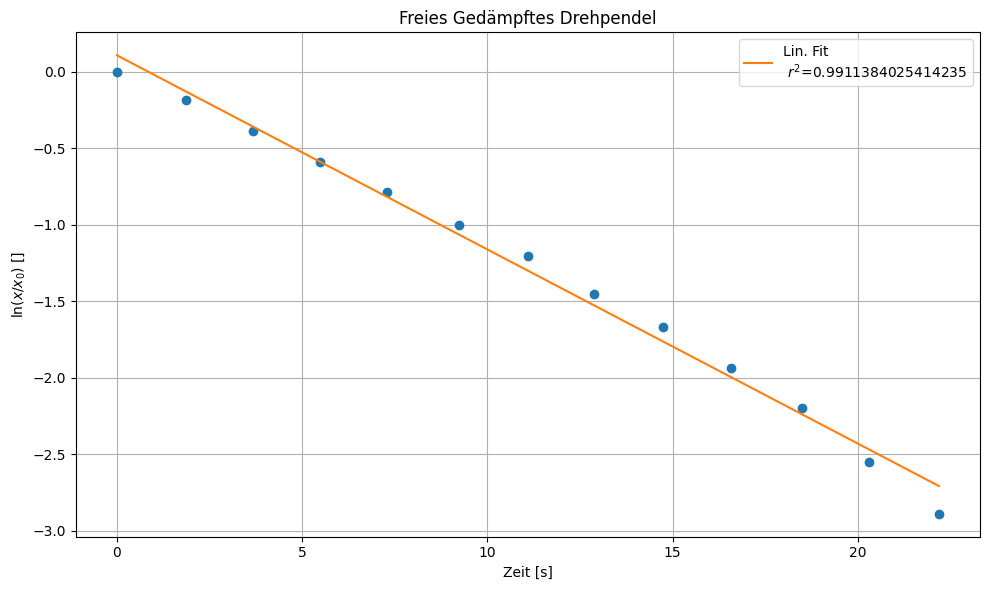

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

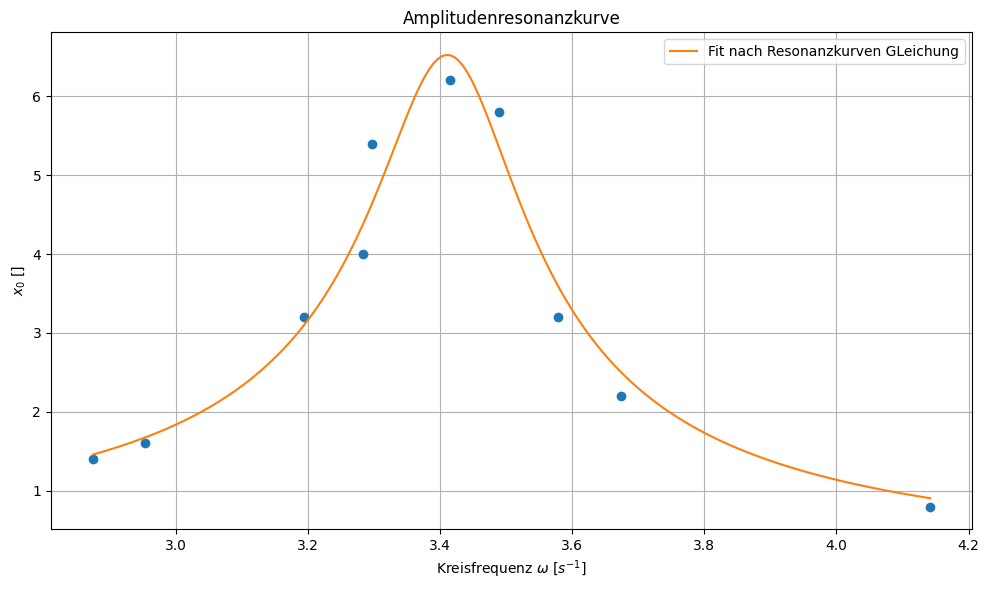

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [36]:

t = np.array([0, 1.88, 3.68, 5.49, 7.29, 9.23, 11.09, 12.89, 14.73, 16.59, 18.49, 20.29, 22.19])
x = np.array([18, 15, 12.2, 10, 8.2, 6.6, 5.4, 4.2, 3.4, 2.6, 2, 1.4, 1])

# Dämpfungsstrom = 300mA

tu = unp.uarray(t, 0.2)
xu = unp.uarray(x, 0.1)

T = t[-1]/len(t)

w = 2*np.pi/ufloat(T,0.2)

y = np.log(abs(x)/x[0])

res = linregress(t,y)

n= "\n"

plt.figure(figsize=(10, 6))
plt.plot(t, y, "o")
plt.plot(t, res.slope*t+res.intercept, "-", label=f"Lin. Fit {n} $r^2$={res.rvalue**2}")
plt.ylabel(r"$\ln(x/x_0)$ $[]$")
plt.xlabel(r"Zeit [s]")
plt.legend()
plt.title("Freies Gedämpftes Drehpendel")
plt.tight_layout()
plt.grid()
plt.show()

display(Latex(fr"$$\omega_d = {w:.2f}$$"))

display(Latex(fr"$$\delta = {abs(res.slope):.3f} \pm {res.stderr:.3f}$$"))

w0 = unp.sqrt(ufloat(abs(res.slope), res.stderr)**2 + w**2)

display(Latex(fr"$$\omega_0 = {w0:.3f}$$"))

display(Latex(fr"$$Q_{{frei}} = {w0/(2*ufloat(abs(res.slope), res.stderr)):.3f}$$"))






# Getriebener 

w0 = unp.nominal_values(w0)


T = np.array([18.4, 18.01, 19.06, 15.17, 21.86, 21.28, 19.67, 19.14, 17.1, 17.56])/10

f = 1/T

x0 = np.array([6.2,5.8,5.4, 0.8, 1.4, 1.6, 3.2, 4, 2.2, 3.2])

w = f * np.pi * 2

w0 = w[0]

def resonanz(w, a, delta):
    return (a) / np.sqrt((unp.nominal_values(w0)**2 - w**2)**2 + 4*(delta**2)*(w**2))

p0= [2, 0.1]

res, pcov = curve_fit(resonanz, w, x0, p0=p0)

a, delta_fit = res
a_err,delta_err = np.sqrt(np.diag(pcov))


w_fit = np.linspace(min(w),max(w),200)

plt.figure(figsize=(10, 6))
plt.plot(w, x0, "o")
plt.plot(w_fit,resonanz(w_fit, a, delta_fit), "-", label="Fit nach Resonanzkurven GLeichung")
plt.ylabel(r"$x_0$ $[]$")
plt.xlabel(r"Kreisfrequenz $\omega~[s^{{-1}}]$")
plt.legend()
plt.title("Amplitudenresonanzkurve")
plt.tight_layout()
plt.grid()
plt.show()


display(Latex(fr"$$\delta = {delta_fit:.3f} \pm {delta_err:.3f}$$"))

display(Latex(fr"$$Q_{{erzwungen}} = {w0/(2*ufloat(delta_fit, delta_err)):.3f}$$"))






## Gekoppelte Schwingungen

In diesem Experiment werden gekoppelte Drehpendel untersucht, um die Eigenfrequenzen der Normalmoden, die Schwebungsfrequenz sowie den Kopplungsgrad des Systems zu bestimmen.

### Durchführung und Versuchsaufbau

Zwei Drehpendel sind über ein Kopplungsgewicht miteinander verbunden. Die Stärke der Kopplung wird durch die Kopplungslänge \(l\) und das Kopplungsgewicht bestimmt. Es werden Größen und Masse des Kopplungsgewichts gemessen.

Im Schwebungsfall wird ein Pendel ausgelenkt, während das andere in Ruhelage verbleibt. Die Schwebungsdauer ist

$$
T_S = \frac{\pi}{\omega_S}.
$$

und die Schwebungsfrequenz ist 

$$
\omega_S = \frac{\omega_1 - \omega_0}{2},
$$

Für die Schwingungsdauer gilt

$$
T_2 = \frac{2\pi}{\omega_2}.
$$

woraus die kreisfrequenz

$$
\omega_2 = \frac{\omega_1 + \omega_0}{2},
$$

bestimmt werden kann.

Aus den Beiden Frequenzen folgt für die Eigenfrequenzen $w_0$, $w_1$:

$$
w_1 = w_s+w_2 \quad \quad w_0 = w_2-w_s
$$


Zusätzlich folgt für den Kopplungsgrad:

$$
K = \dfrac{2\omega_s \omega_2}{\omega_s^2 + \omega_2^2}.
$$

### Verwendete Geräte und Unsicherheiten

– **Stoppuhr** $\pm$ 200ms

– **Lineal** $\pm$ 1cm

### Systematische Unsicherheiten


In [48]:
# Gleichsinnig

# L = (86 \pm 1)cm

# l = (49 \pm 1)cm


# w_gl = (1/17.72/10)*2*np.pi

# w_geg = (1/16.81/10)*2*np.pi


w_s = 1/(ufloat(32.95, 1))*np.pi

w_2 = 1/(ufloat(8.67,1)/5)*2*np.pi


w1 = w_s + w_2

w0 = w_2 - w_s

K = 2*w_s*w_2/(w_2**2+w_s**2)


display(Latex(rf"$$\omega_s = {w_s:.4f}$$"))
display(Latex(rf"$$\omega_2 = {w_2:.2f}$$"))


# display(Latex(rf"$$\omega_{{gl}} = {w_gl:.2f}$$"))
# display(Latex(rf"$$\omega_{{geg}} = {w_geg:.2f}$$"))

display(Latex(rf"$$\omega_0 = {w0:.2f}$$"))
display(Latex(rf"$$\omega_1 = {w1:.2f}$$"))

display(Latex(rf"$$K = {K:.3f}$$"))






<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>